# **Импорты**

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Настройка вывода графиков прямо в ноутбуке
%matplotlib inline

# Настройка устройства (GPU если доступен)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


# **ЗАГРУЗКА И ПРЕДОБРАБОТКА**

In [ ]:

# Используем встроенный в keras/tensorflow загрузчик, так как он был в исходнике,
# либо можно загрузить через torchvision. Для простоты возьмем numpy-массивы изmnist.
from tensorflow.keras.datasets import mnist
(X_train_np, y_train_np), (_, _) = mnist.load_data()

# Нормировка в диапазон [0, 1]
X_train_np = X_train_np.astype('float32') / 255.0

# Фильтрация по маске (только цифры 0, 1 и 3)
numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train_np])
X_train_np = X_train_np[mask]
y_train_np = y_train_np[mask]

# Перевод в тензоры PyTorch и изменение размерности под формат (Batch, Channels, Height, Width)
# (N, 28, 28) -> (N, 1, 28, 28)
X_train_tensor = torch.tensor(X_train_np).unsqueeze(1)
y_train_tensor = torch.tensor(y_train_np)

# Создание DataLoader
dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset, batch_size=128, shuffle=True)

print(f"Размер отфильтрованной выборки в PyTorch: {X_train_tensor.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Размер отфильтрованной выборки в PyTorch: torch.Size([18796, 1, 28, 28])


# **АРХИТЕКТУРА СВЕРТОЧНОГО АВТОКОДИРОВЩИКА**

In [ ]:

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.features = nn.Sequential(
            # Вход: 1 x 28 x 28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Выход: 32 x 14 x 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Выход: 64 x 7 x 7
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 2) # Bottleneck: 2-мерное скрытое пространство (linear)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64 * 7 * 7),
            nn.ReLU()
        )
        self.deconv = nn.Sequential(
            # Вход: 64 x 7 x 7
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 64 x 14 x 14
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 32 x 28 x 28
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid() # Значения пикселей от 0 до 1
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 7, 7)
        x = self.deconv(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

# Инициализация моделей
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Скорость обучения 0.001 по условию

# **ФУНКЦИЯ ОТРИСОВКИ**

In [ ]:

def plot_latent_space(encoder_model, epoch, current_loss):
    encoder_model.eval()
    with torch.no_grad():
        # Прогоняем всю тренировочную выборку через энкодер
        inputs = X_train_tensor.to(device)
        latent_representations = encoder_model(inputs).cpu().numpy()


    print(f'*** ЭПОХА: {epoch}, loss: {current_loss:.5f} ***')


    plt.figure(dpi=100)
    scatter = plt.scatter(latent_representations[:, 0], latent_representations[:, 1],
                         c=y_train_np, alpha=0.6, s=5, cmap='tab10')
    plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')

    # Сохранение по логике исходного ноутбука
    paths = glob.glob('image_*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')
    plt.show()

# Очистка старых картинок перед стартом
for p in glob.glob('image_*.jpg'):
    os.remove(p)

# **ЦИКЛ ОБУЧЕНИЯ**

Старт обучения свёрточного автокодировщика на PyTorch...
________________________
*** ЭПОХА: 1, loss: 0.05130 ***
________________________


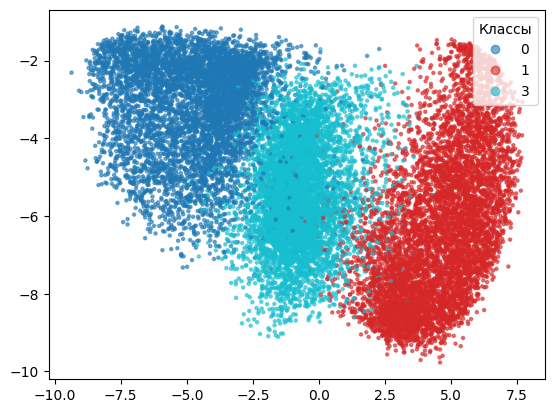

________________________
*** ЭПОХА: 2, loss: 0.03250 ***
________________________


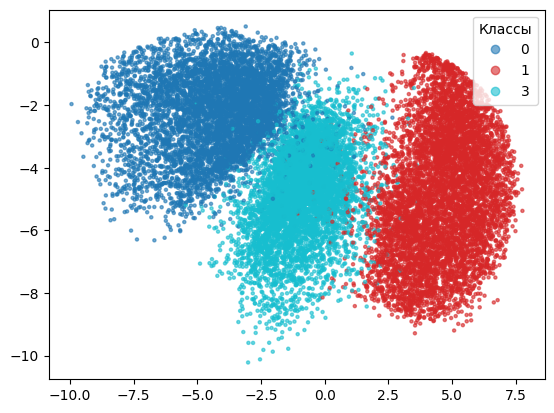

________________________
*** ЭПОХА: 3, loss: 0.03056 ***
________________________


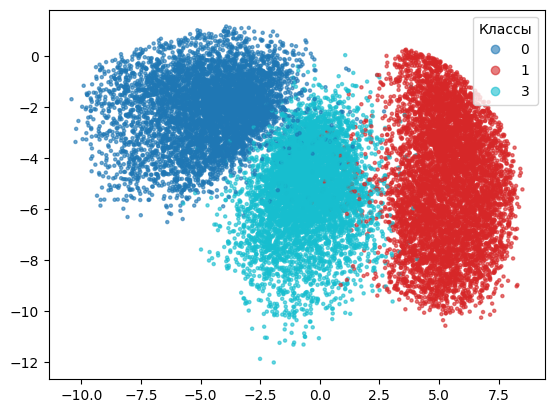

________________________
*** ЭПОХА: 4, loss: 0.02978 ***
________________________


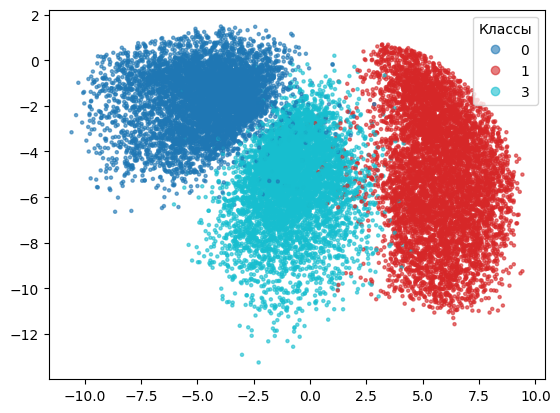

________________________
*** ЭПОХА: 5, loss: 0.02911 ***
________________________


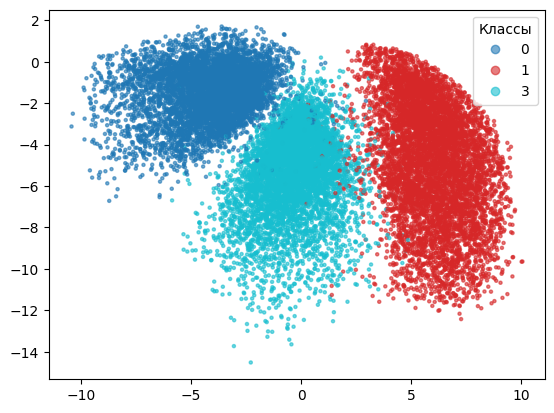

________________________
*** ЭПОХА: 6, loss: 0.02885 ***
________________________


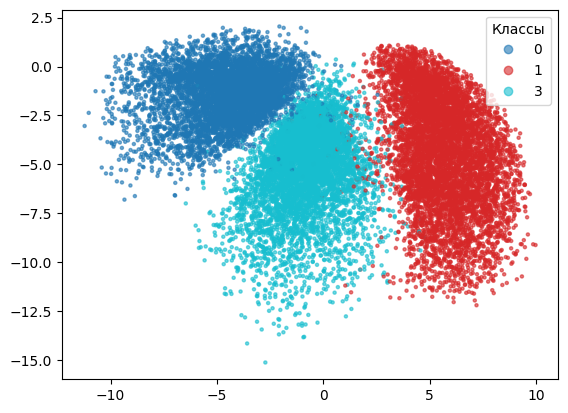

________________________
*** ЭПОХА: 7, loss: 0.02858 ***
________________________


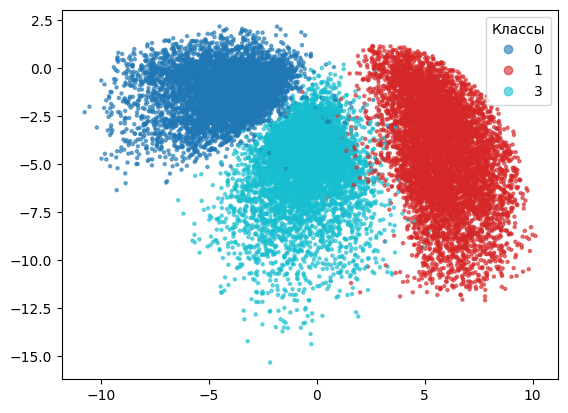

________________________
*** ЭПОХА: 8, loss: 0.02841 ***
________________________


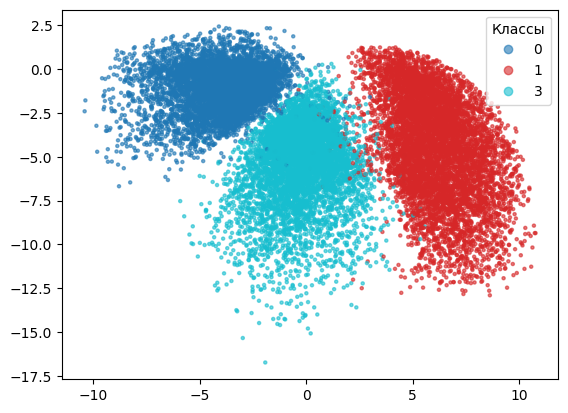

________________________
*** ЭПОХА: 9, loss: 0.02829 ***
________________________


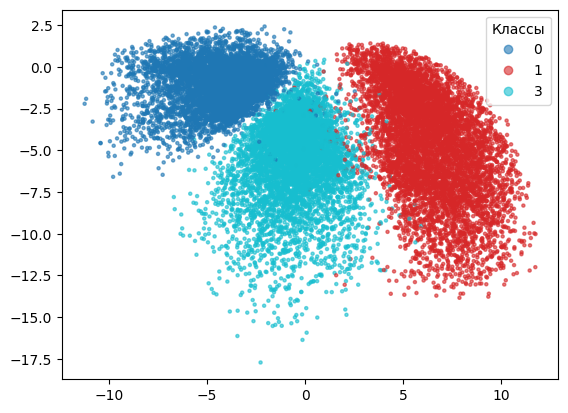

________________________
*** ЭПОХА: 10, loss: 0.02815 ***
________________________


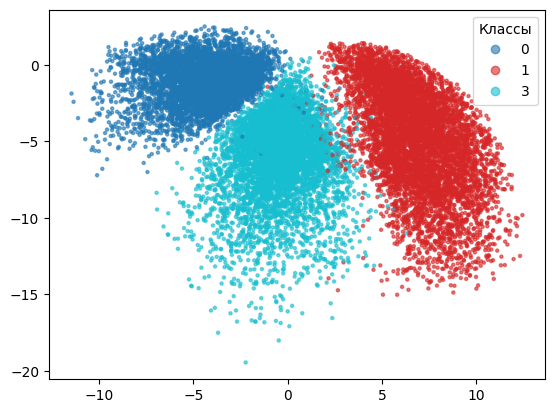


Итоговая ошибка MSE на 10-й эпохе: 0.02815
Успех! Требуемое условие задания (MSE < 0.034) на PyTorch полностью выполнено.


In [ ]:

epochs = 10
print("Старт обучения свёрточного автокодировщика на PyTorch...")

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой ход
        outputs = model(batch_x)

        # Цель автокодировщика — восстановить вход (сравниваем outputs и batch_x)
        loss = criterion(outputs, batch_x)

        # Обратный ход и оптимизация
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # Вызов кастомного «коллбэка» отрисовки в конце эпохи
    plot_latent_space(model.encoder, epoch, epoch_loss)

# Финальная проверка критерия выполнения задания

print(f"Итоговая ошибка MSE на 10-й эпохе: {epoch_loss:.5f}")
if epoch_loss < 0.034:
    print("Успех! Требуемое условие задания (MSE < 0.034) на PyTorch полностью выполнено.")
else:
    print("Внимание: Порог не пройден. Попробуйте запустить обучение заново.")
